# **Análisis de Proyecciones Poblacionales - INE**
# **Sprint 4: Tendencias Demográficas y Ajuste de Estrategia**

**Pregunta de negocio (Hipótesis 1):** ¿Debemos ajustar nuestros segmentos de clientes actuales basándonos en las proyecciones de población oficiales del INE?

***Segmentos de interés:**

| Segmento | Rango de edad | Clientes Esperados |
|---|---|---|
| Jóvenes  | 18-30 | TBD |
| Jóvenes -  Adultos | 31-40 | TBD |
| Adultos | 41-50 | TBD |
| Senior | 51-60 | TBD |
|Senior - Mayores | 61+| TBD |

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os, glob, platform
import numpy as np

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

BG, TXT, ACCENT = '#0d1b3e', '#ffffff', '#a8c8f0'
C_BLUE, C_ORANGE, C_TEAL, C_VIOLET, C_RED, C_GREEN = '#1f77b4', '#f4a261', '#2ec4b6', '#8A2BE2', '#d62728', '#2ca02c'

ANIO_INICIO, ANIO_FIN = 2026, 2036

def encontrar_archivo(nombre):
    ruta_local = os.path.join(os.getcwd(), nombre)
    if os.path.exists(ruta_local): return ruta_local
    home = os.path.expanduser('~')
    resultados = glob.glob(os.path.join(home, '**', nombre), recursive=True)
    if resultados: return resultados[0]
    raiz = 'C:\\\\' if platform.system() == 'Windows' else '/'
    resultados = glob.glob(os.path.join(raiz, '**', nombre), recursive=True)
    return resultados[0] if resultados else None

def cargar_csv(nombre, sep=','):
    path = encontrar_archivo(nombre)
    if not path: raise FileNotFoundError(f'No se encontró: {nombre}')
    print(f'✓ {nombre}')
    return pd.read_csv(path, sep=sep, encoding='utf-8-sig', decimal=',')

print('Cargando datos...')
df_edad_raw   = cargar_csv('06-15-2026_edad_media_2024-2039.csv', sep=';')
df_indice_raw = cargar_csv('06-15-2026_indice_envejecimiento.csv', sep=';')
df_tasa_raw   = cargar_csv('06-15-2026_tasa_dependencia_poblacion_mayor.csv', sep=';')
df_pob_raw    = cargar_csv('06-15-2026_poblacion_2024-2074.csv', sep=';')
df_banco      = cargar_csv('06-08-2026_Clean.csv', sep=',')

for df in [df_edad_raw, df_indice_raw, df_tasa_raw, df_pob_raw]:
    df.columns = [c.strip() for c in df.columns]

print('\n✓ Datos cargados')


Cargando datos...
✓ 06-15-2026_edad_media_2024-2039.csv
✓ 06-15-2026_indice_envejecimiento.csv
✓ 06-15-2026_tasa_dependencia_poblacion_mayor.csv
✓ 06-15-2026_poblacion_2024-2074.csv
✓ 06-08-2026_Clean.csv

✓ Datos cargados


In [3]:
# Definir rangos de edad
rango_edades = {
    "Jóvenes":         {"edad_min": 18, "edad_max": 30},
    "Jóvenes-Adultos": {"edad_min": 31, "edad_max": 40},
    "Adultos":         {"edad_min": 41, "edad_max": 50},
    "Senior":          {"edad_min": 51, "edad_max": 60},
    "Senior-Mayores":  {"edad_min": 61, "edad_max": 100}
}

def asignar_rango(age):
    for nombre, info in rango_edades.items():
        if info['edad_min'] <= age <= info['edad_max']:
            return nombre
    return None

df_banco['rango'] = df_banco['age'].apply(asignar_rango)
clientes_por_rango = df_banco[df_banco['rango'].notna()]['rango'].value_counts()

orden_rangos = ["Jóvenes", "Jóvenes-Adultos", "Adultos", "Senior", "Senior-Mayores"]

print('\n' + '='*80)
print('📊 CLIENTES DEL BANCO POR RANGO')
print('='*80)
for rango_name in orden_rangos:
    info = rango_edades[rango_name]
    count = clientes_por_rango.get(rango_name, 0)
    print(f'{rango_name} ({info["edad_min"]}-{info["edad_max"]}): {count} clientes')
print('='*80)



📊 CLIENTES DEL BANCO POR RANGO
Jóvenes (18-30): 2003 clientes
Jóvenes-Adultos (31-40): 4196 clientes
Adultos (41-50): 2495 clientes
Senior (51-60): 1857 clientes
Senior-Mayores (61-100): 611 clientes


In [4]:
# LIMPIEZA INE — filtrar solo Total Nacional

# — EDAD MEDIA —
df_edad = df_edad_raw.copy()
df_edad.columns = [c.strip() for c in df_edad.columns]
# Filtrar Total Nacional (descarta provincias y desagregación por sexo)
mask_edad = (df_edad['Sexo'].str.strip() == 'Total') & (df_edad['Provincias'].str.strip() == 'Total Nacional')
df_edad = df_edad[mask_edad][['Periodo', 'Total']].copy()
df_edad['Periodo'] = pd.to_numeric(df_edad['Periodo'], errors='coerce')
df_edad = df_edad.dropna(subset=['Periodo'])
df_edad['Periodo'] = df_edad['Periodo'].astype(int)
df_edad = df_edad[df_edad['Periodo'].between(ANIO_INICIO, ANIO_FIN)].sort_values('Periodo')
df_edad.rename(columns={'Total': 'edad_media'}, inplace=True)
df_edad['edad_media'] = pd.to_numeric(df_edad['edad_media'], errors='coerce')
print(f'✓ Edad media: {len(df_edad)} filas')

# — ÍNDICE ENVEJECIMIENTO —
df_indice = df_indice_raw.copy()
df_indice.columns = [c.strip() for c in df_indice.columns]
df_indice['Periodo'] = pd.to_numeric(df_indice['Periodo'], errors='coerce')
df_indice = df_indice.dropna(subset=['Periodo'])
df_indice['Periodo'] = df_indice['Periodo'].astype(int)
df_indice = df_indice[df_indice['Periodo'].between(ANIO_INICIO, ANIO_FIN)].sort_values('Periodo')
df_indice.rename(columns={'Total': 'indice_envejecimiento'}, inplace=True)
df_indice['indice_envejecimiento'] = pd.to_numeric(df_indice['indice_envejecimiento'], errors='coerce')
print(f'✓ Índice envejecimiento: {len(df_indice)} filas')

# — TASA DEPENDENCIA —
df_tasa = df_tasa_raw.copy()
df_tasa.columns = [c.strip() for c in df_tasa.columns]
df_tasa['Periodo'] = pd.to_numeric(df_tasa['Periodo'], errors='coerce')
df_tasa = df_tasa.dropna(subset=['Periodo'])
df_tasa['Periodo'] = df_tasa['Periodo'].astype(int)
df_tasa = df_tasa[df_tasa['Periodo'].between(ANIO_INICIO, ANIO_FIN)].sort_values('Periodo')
df_tasa.rename(columns={'Total': 'tasa_dependencia'}, inplace=True)
df_tasa['tasa_dependencia'] = pd.to_numeric(df_tasa['tasa_dependencia'], errors='coerce')
print(f'✓ Tasa dependencia: {len(df_tasa)} filas')

print('\n✓ INE limpio')


✓ Edad media: 11 filas
✓ Índice envejecimiento: 11 filas
✓ Tasa dependencia: 11 filas

✓ INE limpio


In [5]:
# POBLACIÓN — la columna Edad viene como '18 años', '0 años', etc.
df_pob = df_pob_raw.copy()
df_pob.columns = [c.strip() for c in df_pob.columns]

# Filtrar solo Sexo == Total (evitar duplicar Hombres + Mujeres)
df_pob = df_pob[df_pob['Sexo'].str.strip() == 'Total'].copy()

# Extraer número de edad desde '18 años' → 18
df_pob['edad'] = df_pob['Edad'].str.extract(r'(\d+)').astype(float)

# Limpiar Periodo
df_pob['Periodo'] = pd.to_numeric(df_pob['Periodo'], errors='coerce')
df_pob = df_pob.dropna(subset=['Periodo', 'edad'])
df_pob['Periodo'] = df_pob['Periodo'].astype(int)

# Limpiar Total (formato español: 1.234.567,89 → float)
df_pob['poblacion'] = (
    df_pob['Total']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df_pob['poblacion'] = pd.to_numeric(df_pob['poblacion'], errors='coerce')

# Filtrar rango de años
df_pob = df_pob[df_pob['Periodo'].between(ANIO_INICIO, ANIO_FIN)]
df_pob = df_pob.dropna(subset=['edad', 'poblacion'])

# Asignar rango y agrupar
df_pob['rango'] = df_pob['edad'].apply(asignar_rango)
df_pob = df_pob.dropna(subset=['rango'])

df_pob_rango = df_pob.groupby(['Periodo', 'rango'])['poblacion'].sum().reset_index()

print('✓ Población procesada')
print(f'  Periodos: {sorted(df_pob_rango["Periodo"].unique())}')
print(f'  Rango: {df_pob_rango["rango"].unique().tolist()}')
print(df_pob_rango.pivot(index="rango", columns="Periodo", values="poblacion").to_string())


✓ Población procesada
  Periodos: [np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034), np.int64(2035), np.int64(2036)]
  Rango: ['Adultos', 'Jóvenes', 'Jóvenes-Adultos', 'Senior', 'Senior-Mayores']
Periodo                  2026          2027          2028          2029          2030          2031          2032          2033          2034          2035          2036
rango                                                                                                                                                                    
Adultos          7.760299e+06  7.664353e+06  7.540857e+06  7.413706e+06  7.284696e+06  7.173866e+06  7.070072e+06  6.988364e+06  6.933127e+06  6.894973e+06  6.859836e+06
Jóvenes          7.279147e+06  7.509070e+06  7.691926e+06  7.834786e+06  7.949272e+06  8.018102e+06  8.033287e+06  8.041487e+06  8.029530e+06  7.984829e+06  7.909925e+06
Jóvenes-Adultos  6.120723e+06 

In [6]:
# INTEGRACIÓN Y COBERTURA
df_ine = df_edad[['Periodo', 'edad_media']].copy()
df_ine = df_ine.merge(df_indice[['Periodo', 'indice_envejecimiento']], on='Periodo', how='left')
df_ine = df_ine.merge(df_tasa[['Periodo', 'tasa_dependencia']], on='Periodo', how='left')

print('\n' + '='*90)
print('TABLA DE COBERTURA — CLIENTES vs POBLACIÓN (POR RANGO)')
print('='*90)

tabla_cob = []
for rango_name in orden_rangos:
    clientes = clientes_por_rango.get(rango_name, 0)
    pob_inicio = df_pob_rango[(df_pob_rango['Periodo']==ANIO_INICIO) & (df_pob_rango['rango']==rango_name)]['poblacion'].values
    pob_fin    = df_pob_rango[(df_pob_rango['Periodo']==ANIO_FIN)    & (df_pob_rango['rango']==rango_name)]['poblacion'].values

    if len(pob_inicio) > 0 and len(pob_fin) > 0:
        p_ini, p_fin = pob_inicio[0], pob_fin[0]
        var_pob = ((p_fin - p_ini) / p_ini) * 100
        tabla_cob.append({
            'rango':                         rango_name,
            'Clientes':                      int(clientes),
            f'Pob {ANIO_INICIO} (M)':        round(p_ini / 1_000_000, 3),
            f'Pob {ANIO_FIN} (M)':           round(p_fin / 1_000_000, 3),
            'Var %':                         round(var_pob, 2),
            f'Clientes/M {ANIO_INICIO}':     round((clientes / p_ini) * 1_000_000, 1),
            f'Clientes/M {ANIO_FIN}':        round((clientes / p_fin) * 1_000_000, 1)
        })

df_cob = pd.DataFrame(tabla_cob)
if not df_cob.empty:
    print(df_cob.to_string(index=False))
else:
    print('⚠️  df_cob vacío — revisar df_pob_rango')
print('='*90)



TABLA DE COBERTURA — CLIENTES vs POBLACIÓN (POR RANGO)
          rango  Clientes  Pob 2026 (M)  Pob 2036 (M)  Var %  Clientes/M 2026  Clientes/M 2036
        Jóvenes      2003         7.279         7.910   8.67            275.2            253.2
Jóvenes-Adultos      4196         6.121         6.701   9.48            685.5            626.2
        Adultos      2495         7.760         6.860 -11.60            321.5            363.7
         Senior      1857         7.680         8.031   4.57            241.8            231.2
 Senior-Mayores       611        13.164        16.560  25.80             46.4             36.9


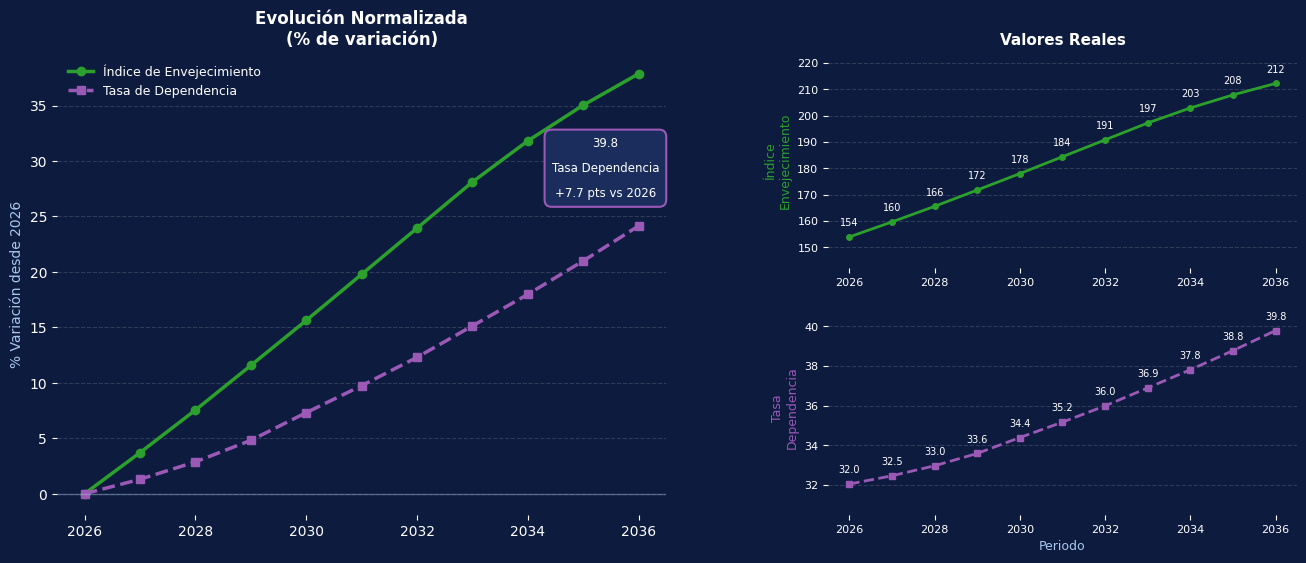

✓ Gráfico 1 — normalizado + valores reales lado a lado, con etiquetas
✓ Gráfico 1 — normalizado + valores reales lado a lado


In [ ]:
import matplotlib.gridspec as gridspec

C_VIOLET = '#9b59b6'

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.3, 1], height_ratios=[1, 1], wspace=0.3, hspace=0.15)

df_ine['indice_norm'] = (df_ine['indice_envejecimiento'] / df_ine['indice_envejecimiento'].iloc[0] - 1) * 100
df_ine['tasa_norm']   = (df_ine['tasa_dependencia']      / df_ine['tasa_dependencia'].iloc[0]      - 1) * 100

# ── IZQUIERDA: gráfico normalizado con tarjeta KPI (ocupa las dos filas) ──
ax = fig.add_subplot(gs[:, 0])
ax.set_facecolor(BG)
ax.plot(df_ine['Periodo'], df_ine['indice_norm'],
        color=C_GREEN, linewidth=2.5, marker='o', label='Índice de Envejecimiento')
ax.plot(df_ine['Periodo'], df_ine['tasa_norm'],
        color=C_VIOLET, linewidth=2.5, marker='s', linestyle='--', label='Tasa de Dependencia')
ax.set_ylabel(f'% Variación desde {ANIO_INICIO}', color=ACCENT, fontsize=10)
ax.set_title('Evolución Normalizada\n(% de variación)', color=TXT, fontsize=12, fontweight='bold')
ax.tick_params(colors=TXT)
for sp in ax.spines.values(): sp.set_visible(False)
ax.axhline(y=0, color=ACCENT, linewidth=1, alpha=0.4)
ax.grid(axis='y', color='#fff', linestyle='--', alpha=0.15)
ax.legend(loc='upper left', facecolor=BG, labelcolor=TXT, frameon=False, fontsize=9)

tasa_inicio = df_ine['tasa_dependencia'].iloc[0]
tasa_fin    = df_ine['tasa_dependencia'].iloc[-1]
tasa_cambio = tasa_fin - tasa_inicio
kpi_text = f"{tasa_fin:.1f}\nTasa Dependencia\n{tasa_cambio:+.1f} pts vs {ANIO_INICIO}"
ax.text(0.90, 0.75, kpi_text, transform=ax.transAxes,
        ha='center', va='center', color=TXT, fontsize=8.5, linespacing=2.2,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#1a2d5c', edgecolor=C_VIOLET, linewidth=1.5))

# ── DERECHA ARRIBA: Índice de Envejecimiento (valores reales) ──
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(BG)
ax1.plot(df_ine['Periodo'], df_ine['indice_envejecimiento'],
         color=C_GREEN, linewidth=2, marker='o', markersize=4)
for x, y in zip(df_ine['Periodo'], df_ine['indice_envejecimiento']):
    ax1.annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=7, color=TXT)
ax1.set_ylabel('Índice\nEnvejecimiento', color=C_GREEN, fontsize=9)
ax1.set_title('Valores Absolutos', color=TXT, fontsize=11, fontweight='bold')
ax1.tick_params(colors=TXT, labelsize=8)
for sp in ax1.spines.values(): sp.set_visible(False)
ax1.grid(axis='y', color='#fff', linestyle='--', alpha=0.15)
ax1.margins(y=0.2)

# ── DERECHA ABAJO: Tasa de Dependencia (valores reales) ──
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(BG)
ax2.plot(df_ine['Periodo'], df_ine['tasa_dependencia'],
         color=C_VIOLET, linewidth=2, marker='s', markersize=4, linestyle='--')
for x, y in zip(df_ine['Periodo'], df_ine['tasa_dependencia']):
    ax2.annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=7, color=TXT)
ax2.set_ylabel('Tasa\nDependencia', color=C_VIOLET, fontsize=9)
ax2.set_xlabel('Periodo', color=ACCENT, fontsize=9)
ax2.tick_params(colors=TXT, labelsize=8)
for sp in ax2.spines.values(): sp.set_visible(False)
ax2.grid(axis='y', color='#fff', linestyle='--', alpha=0.15)
ax2.margins(y=0.2)

plt.savefig('grafico1_completo.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Gráfico 1 — normalizado + valores reales lado a lado, con etiquetas')
print('✓ Gráfico 1 — normalizado + valores reales lado a lado')

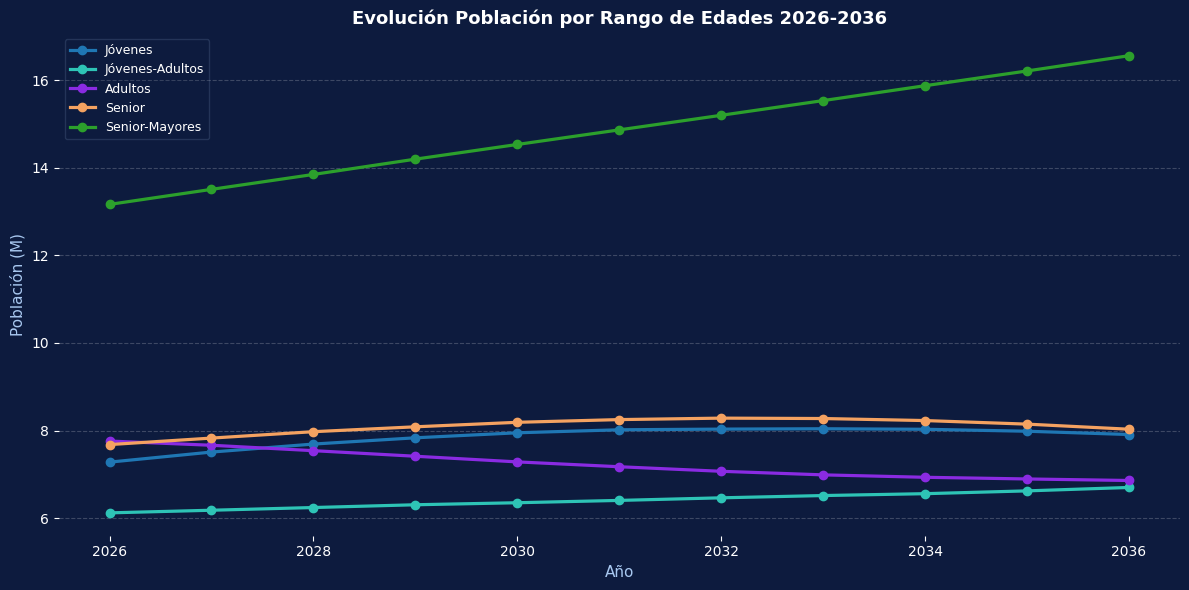

✓ Gráfico 2


In [ ]:
# GRÁFICO 2 — Evolución Población por Cluster
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
colores = {  
    'Jóvenes': C_BLUE,
    'Jóvenes-Adultos':    C_TEAL,
    'Adultos':     C_VIOLET,
    'Senior':     C_ORANGE,
    'Senior-Mayores': C_GREEN
}
for rango_name, color in colores.items():
    datos = df_pob_rango[df_pob_rango['rango'] == rango_name].sort_values('Periodo')
    ax.plot(datos['Periodo'], datos['poblacion'] / 1_000_000,
            color=color, linewidth=2.3, marker='o', label= rango_name)
ax.set_title(f'Evolución Población por Rango de Edades {ANIO_INICIO}-{ANIO_FIN}',
             color=TXT, fontsize=13, fontweight='bold')
ax.set_xlabel('Año', color=ACCENT, fontsize=11)
ax.set_ylabel('Población (M)', color=ACCENT, fontsize=11)
ax.tick_params(colors=TXT)
for sp in ax.spines.values(): sp.set_visible(False)
ax.grid(axis='y', color='#fff', linestyle='--', alpha=0.2)
ax.legend(framealpha=0.15, facecolor=BG, edgecolor=ACCENT, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.savefig('grafico2_poblacion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Gráfico 2')


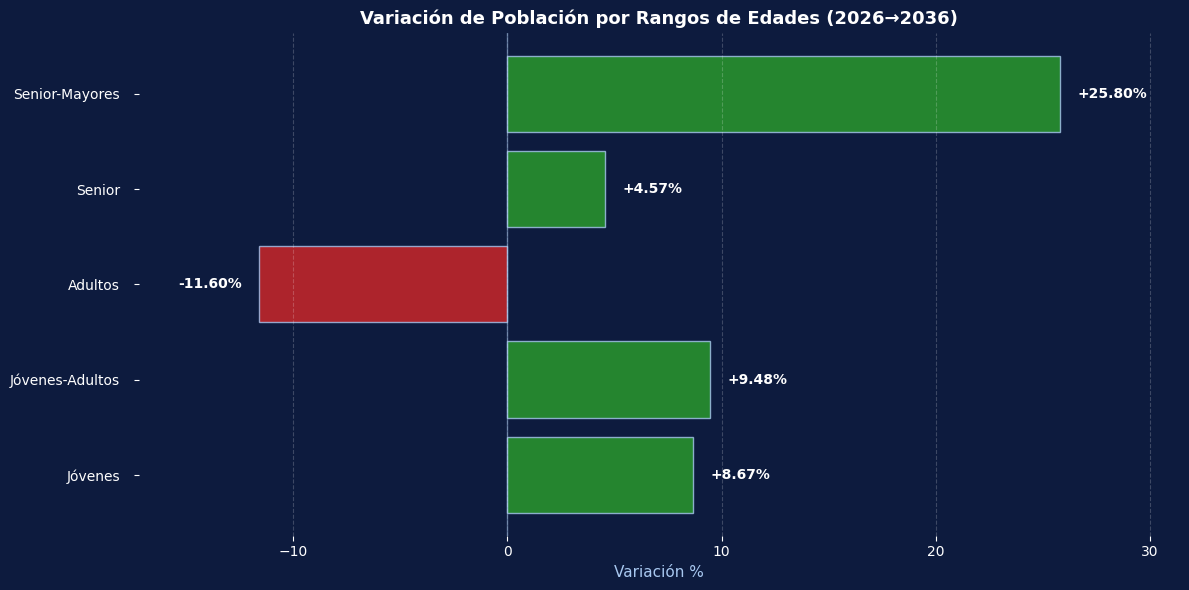

✓ Gráfico 3


In [30]:
# GRÁFICO 3 — Variación de Población por Cluster
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
clusters_list = df_cob['rango'].tolist()
variaciones   = df_cob['Var %'].tolist()
colors = [C_GREEN if v > 0 else C_RED for v in variaciones]
ax.barh(clusters_list, variaciones, color=colors, alpha=0.8, edgecolor=ACCENT)

# Dar más margen para que las etiquetas no choquen con los nombres del eje Y
max_val = max(variaciones)
min_val = min(variaciones)
margen = (max_val - min_val) * 0.15
ax.set_xlim(min_val - margen, max_val + margen)

for i, (c, v) in enumerate(zip(clusters_list, variaciones)):
    ha = 'left' if v > 0 else 'right'
    offset = 0.8 if v > 0 else -0.8   # offset más amplio para separar del borde
    ax.text(v + offset, i, f'{v:+.2f}%', va='center', ha=ha, color=TXT, fontweight='bold')

ax.set_title(f'Variación de Población por Rangos de Edades ({ANIO_INICIO}→{ANIO_FIN})',
             color=TXT, fontsize=13, fontweight='bold')
ax.set_xlabel('Variación %', color=ACCENT, fontsize=11)
ax.tick_params(colors=TXT, axis='y', pad=10)   # separa nombres del eje Y de las barras
ax.tick_params(colors=TXT, axis='x')
for sp in ax.spines.values(): sp.set_visible(False)
ax.axvline(x=0, color=ACCENT, linewidth=1, alpha=0.5)
ax.grid(axis='x', color='#fff', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('grafico3_variacion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Gráfico 3')

In [33]:
print('\n' + '='*90)
print('✅ RESPUESTA A HIPÓTESIS 1')
print('='*90)

indice_inicio = df_ine['indice_envejecimiento'].iloc[0]
indice_fin    = df_ine['indice_envejecimiento'].iloc[-1]
indice_cambio = indice_fin - indice_inicio

edad_inicio   = df_ine['edad_media'].iloc[0]
edad_fin      = df_ine['edad_media'].iloc[-1]
edad_cambio   = edad_fin - edad_inicio

tasa_inicio   = df_ine['tasa_dependencia'].iloc[0]
tasa_fin      = df_ine['tasa_dependencia'].iloc[-1]

# Segmento con mayor y menor variación
rango_max = df_cob.loc[df_cob['Var %'].idxmax(), 'rango']
var_max   = df_cob['Var %'].max()
rango_min = df_cob.loc[df_cob['Var %'].idxmin(), 'rango']
var_min   = df_cob['Var %'].min()

print(f"""
📈 ENVEJECIMIENTO DEMOGRÁFICO ({ANIO_INICIO}-{ANIO_FIN}):
   Índice de envejecimiento: {indice_inicio:.1f} → {indice_fin:.1f}  ({indice_cambio:+.1f} puntos)
   Edad media:               {edad_inicio:.2f} → {edad_fin:.2f} años  ({edad_cambio:+.2f} años)
   Tasa de dependencia:      {tasa_inicio:.2f} → {tasa_fin:.2f}  ({tasa_fin - tasa_inicio:+.2f} puntos)

📊 VARIACIÓN DE POBLACIÓN POR RANGO ({ANIO_INICIO}→{ANIO_FIN}):
""")

for _, row in df_cob.iterrows():
    icon = '📈' if row['Var %'] > 0 else '📉'
    print(f"   {row['rango']:20s}  {row['Var %']:+.2f}% {icon}  "
          f"({int(row['Clientes'])} clientes actuales)")

print(f"""
════════════════════════════════════════════════════════════════════════════════
📋 HALLAZGOS CLAVE:

•- En términos absolutos, la tasa de dependencia pasará de {tasa_inicio:.1f} a {tasa_fin:.1f} ,
casi 4 de cada 10 personas dependerán económicamente de la población en edad laboral en {ANIO_FIN}.

• La población española envejecerá progresivamente entre {ANIO_INICIO} y {ANIO_FIN}:
  la edad media subirá {edad_cambio:+.2f} años y el índice de envejecimiento
  aumentará {indice_cambio:+.1f} puntos.

• El rango de mayor crecimiento demográfico es {rango_max} ({var_max:+.2f}%).

• El único rango con contracción demográfica es {rango_min} ({var_min:+.2f}%).

• La cobertura actual del banco (clientes/millón de habitantes) variará
  de forma desigual entre rangos, reflejando tanto el crecimiento poblacional
  como la distribución actual de la cartera.

✅ CONCLUSIÓN:
  Sí, los datos demográficos del INE justifican revisar la estrategia de
  segmentación. Los rangos no crecen al mismo ritmo y uno de ellos se contrae.
""")



✅ RESPUESTA A HIPÓTESIS 1

📈 ENVEJECIMIENTO DEMOGRÁFICO (2026-2036):
   Índice de envejecimiento: 153.9 → 212.2  (+58.3 puntos)
   Edad media:               44.71 → 46.75 años  (+2.04 años)
   Tasa de dependencia:      32.04 → 39.78  (+7.74 puntos)

📊 VARIACIÓN DE POBLACIÓN POR RANGO (2026→2036):

   Jóvenes               +8.67% 📈  (2003 clientes actuales)
   Jóvenes-Adultos       +9.48% 📈  (4196 clientes actuales)
   Adultos               -11.60% 📉  (2495 clientes actuales)
   Senior                +4.57% 📈  (1857 clientes actuales)
   Senior-Mayores        +25.80% 📈  (611 clientes actuales)

════════════════════════════════════════════════════════════════════════════════
📋 HALLAZGOS CLAVE:

•- En términos absolutos, la tasa de dependencia pasará de 32.0 a 39.8 ,
casi 4 de cada 10 personas dependerán económicamente de la población en edad laboral en 2036.

• La población española envejecerá progresivamente entre 2026 y 2036:
  la edad media subirá +2.04 años y el índice de envejecimi

In [34]:
# EXPORTACIÓN
df_cob.to_csv('tabla_cobertura_por_cluster.csv', index=False, sep=';')
df_ine.to_csv('datos_ine_integrados.csv', index=False, sep=';')
df_pob_rango.to_csv('poblacion_por_rango.csv', index=False, sep=';')
print('✓ Archivos exportados')


✓ Archivos exportados


In [37]:
print('Filas df_pob_raw:', len(df_pob_raw))
print('Filas df_edad_raw:', len(df_edad_raw))
print('Filas df_indice_raw:', len(df_indice_raw))
print('Filas df_tasa_raw:', len(df_tasa_raw))

total_bruto = len(df_pob_raw) + len(df_edad_raw) + len(df_indice_raw) + len(df_tasa_raw)
print('TOTAL registros brutos revisados:', total_bruto)

Filas df_pob_raw: 15606
Filas df_edad_raw: 2544
Filas df_indice_raw: 51
Filas df_tasa_raw: 51
TOTAL registros brutos revisados: 18252
